# MSDL-JCI — single-notebook pipeline

The whole project lives here: config + hyperparameters, SQLite entity contract,
utilities (indicators, alignment, tensors), a real-DB run with synthetic fallback,
visualizations, and checks. No training — this repo is a closed negative result.
Leak-free order: align → train-only scaling → window (lookback 28) → t+5 labels.

In [1]:
%matplotlib inline
import os
import sqlite3
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.preprocessing import MinMaxScaler

## Config & hyperparameters

One `Config`, env-overridable (see `.env.example`). Table 5 defaults baked in.

In [2]:
NB_ROOT = Path.cwd().resolve()
while not (NB_ROOT / "pyproject.toml").exists() and NB_ROOT != NB_ROOT.parent:
    NB_ROOT = NB_ROOT.parent
load_dotenv(NB_ROOT / ".env")

_raw_db = Path(os.getenv("DATABASE_PATH", "database/main_database.db"))
DB_PATH = _raw_db if _raw_db.is_absolute() else NB_ROOT / _raw_db


@dataclass(frozen=True)
class Config:
    look_back: int = int(os.getenv("ML_LOOK_BACK", "28"))
    horizon: int = int(os.getenv("ML_PREDICTION_HORIZON", "5"))
    hidden_layers: tuple = (50, 25)
    max_iter: int = int(os.getenv("ML_MAX_ITER", "500"))
    seed: int = int(os.getenv("ML_RANDOM_STATE", "42"))
    news_dim: int = 768
    tech_cols: tuple = ("Close", "Volume", "RSI_14", "MACD", "MACD_Signal", "ATR_14", "SMA_20")
    macro_cols: tuple = ("bi_rate", "inflation_rate", "usd_idr")


CFG = Config()
pd.DataFrame(
    [
        ("DB_PATH", str(DB_PATH), "SQLite file"),
        ("look_back", CFG.look_back, "window length"),
        ("horizon", CFG.horizon, "label horizon (t+5)"),
        ("hidden_layers", CFG.hidden_layers, "MLP baseline"),
        ("max_iter", CFG.max_iter, "MLP baseline"),
        ("seed", CFG.seed, "everywhere"),
        ("news_dim", CFG.news_dim, "zero-vector fallback"),
    ],
    columns=["hyperparameter", "value", "notes"],
)

,hyperparameter,value,notes
0,DB_PATH,/home/jwjooth/project/msdl-jci/database/main_d...,SQLite file
1,look_back,28,window length
2,horizon,5,label horizon (t+5)
3,hidden_layers,"(50, 25)",MLP baseline
4,max_iter,500,MLP baseline
5,seed,42,everywhere
6,news_dim,768,zero-vector fallback


## Entity contract + SQLite reader

Verbatim schema of `database/main_database.db`. Every read funnels through
`read_table`, which raises on schema drift.

In [3]:
ENTITY_TABLES = {
    "jci_historical": ("Date", "Close", "High", "Low", "Open", "Volume"),
    "bi_rate": ("Period", "BI-7Day-RR"),
    "inflation_data": ("Periode", "Data Inflasi"),
    "kurs_usdidr": ("Date", "Close", "High", "Low", "Open"),
    "cnbc_ihsg_articles": ("title", "url", "publish_date", "content", "scraped_at"),
    "detik_ihsg_articles": ("title", "url", "snippet", "published", "scraped_at"),
    "kontan_ihsg_articles": ("title", "url", "snippet", "published", "category", "scraped_at"),
}


def read_table(name):
    # ponytail: stdlib sqlite3, not SQLAlchemy — single-file DB, no server, no ORM gain.
    # Upgrade path: sqlalchemy.create_engine if this ever needs pools/concurrency.
    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM [{name}]", con)
    missing = [c for c in ENTITY_TABLES[name] if c not in df.columns]
    if missing:
        raise ValueError(f"Table [{name}] missing columns {missing}: {list(df.columns)}")
    return df


USE_DB = DB_PATH.exists()
print("source:", "SQLite" if USE_DB else "synthetic fallback", "→", DB_PATH)

source: SQLite → /home/jwjooth/project/msdl-jci/database/main_database.db


## Utilities

Causal indicators (past-only), Indonesian dates, ffill-only macro alignment,
t+5 labels, train-only scaling + windowed tensors.

In [4]:
MONTH_MAP = {
    "januari": "01", "jan": "01", "februari": "02", "feb": "02",
    "maret": "03", "mar": "03", "april": "04", "apr": "04",
    "mei": "05", "may": "05", "juni": "06", "jun": "06",
    "juli": "07", "jul": "07", "agustus": "08", "agu": "08", "aug": "08",
    "september": "09", "sep": "09", "oktober": "10", "okt": "10", "oct": "10",
    "november": "11", "nov": "11", "desember": "12", "des": "12", "dec": "12",
}


def parse_id_date(s, day_first=True):
    s = s.astype(str).str.strip().str.lower()
    for k, v in MONTH_MAP.items():
        s = s.str.replace(k, v, regex=False)
    return pd.to_datetime(s, format="mixed", errors="coerce", dayfirst=day_first)


def add_indicators(df):
    c = df["Close"].astype(float)
    h, l = df["High"].astype(float), df["Low"].astype(float)
    d = c.diff()
    ag = d.clip(lower=0).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    al = (-d.clip(upper=0)).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["RSI_14"] = 100 - 100 / (1 + ag / (al + 1e-9))
    df["MACD"] = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    pc = c.shift(1)
    tr = pd.concat([h - l, (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["SMA_20"] = c.rolling(20).mean()
    return df


def load_frames():
    """(jci, bi, inf, kur) raw frames — real DB when present, else synthetic."""
    if USE_DB:
        return (
            read_table("jci_historical"),
            read_table("bi_rate"),
            read_table("inflation_data"),
            read_table("kurs_usdidr"),
        )
    rng = np.random.default_rng(CFG.seed)
    days = pd.date_range("2023-01-02", periods=500, freq="B")
    close = 6900 + np.cumsum(rng.normal(0, 18, len(days)))
    jci = pd.DataFrame({
        "Date": days, "Open": close - 5, "High": close + 10,
        "Low": close - 10, "Close": close, "Volume": 5e7,
    })
    id_months = ["Januari", "Februari", "Maret", "April", "Mei", "Juni",
                 "Juli", "Agustus", "September", "Oktober", "November", "Desember"]
    months = pd.date_range("2023-01-01", periods=17, freq="MS")
    bi = pd.DataFrame({
        "Period": [f"15 {id_months[m.month - 1]} {m.year}" for m in months],
        "BI-7Day-RR": [f"{5.5 + 0.25 * (i % 3)} %" for i in range(len(months))],
    })
    inf = pd.DataFrame({
        "Periode": [f"{id_months[m.month - 1]} {m.year}" for m in months],
        "Data Inflasi": [f"{2.5 + 0.1 * (i % 5)} %" for i in range(len(months))],
    })
    kclose = 15600 + np.cumsum(rng.normal(0, 20, len(days)))
    kur = pd.DataFrame({"Date": days, "Close": kclose})
    return jci, bi, inf, kur


def align(jci, bi, inf, kur):
    jci = jci.copy()
    jci["Date"] = pd.to_datetime(jci["Date"], format="mixed", errors="coerce")
    jci = jci.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    add_indicators(jci)

    bi = bi.copy()
    bi["Date"] = parse_id_date(bi["Period"])
    bi["bi_rate"] = bi["BI-7Day-RR"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    bi = bi.dropna(subset=["Date"]).sort_values("Date")[["Date", "bi_rate"]]

    inf = inf.copy()
    inf["Date"] = parse_id_date(inf["Periode"], day_first=False)
    inf["inflation_rate"] = inf["Data Inflasi"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    inf = inf.dropna(subset=["Date"]).sort_values("Date")[["Date", "inflation_rate"]]

    kur = kur.copy()
    kur["Date"] = pd.to_datetime(kur["Date"], format="mixed", errors="coerce")
    kur["usd_idr"] = pd.to_numeric(kur["Close"].astype(str).str.replace(",", "", regex=False), errors="coerce")
    kur = kur.dropna(subset=["Date"]).sort_values("Date")[["Date", "usd_idr"]]

    m = pd.merge(jci, kur, on="Date", how="left")
    m = pd.merge_asof(m.sort_values("Date"), bi.sort_values("Date"), on="Date", direction="backward")
    m = pd.merge_asof(m.sort_values("Date"), inf.sort_values("Date"), on="Date", direction="backward")
    for col in CFG.macro_cols:  # ffill only — never bfill (future leak)
        m[col] = m[col].ffill()
    m = m.dropna(subset=list(CFG.macro_cols)).reset_index(drop=True)

    fc = m["Close"].shift(-CFG.horizon)
    m["return_5d"] = (fc - m["Close"]) / m["Close"]
    m["target_direction"] = (fc > m["Close"]).astype(float)
    m["future_close"] = fc
    zeros = pd.DataFrame(0.0, index=m.index,  # no DB vectors → zero fallback
                         columns=[f"emb_{i}" for i in range(CFG.news_dim)])
    m = pd.concat([m, zeros], axis=1)
    return m.dropna(subset=list(CFG.tech_cols) + ["future_close"]).reset_index(drop=True)


@dataclass(slots=True)
class Tensors:
    X_tech: np.ndarray
    X_macro: np.ndarray
    X_news: np.ndarray
    y: np.ndarray
    returns_5d: np.ndarray
    dates: np.ndarray
    close: np.ndarray


def make_tensors(df, train_end_idx):
    assert 0 < train_end_idx <= len(df), f"train_end_idx={train_end_idx} out of range"
    tech = list(CFG.tech_cols)
    assert not ({"future_close", "return_5d", "target_direction"} & set(tech))
    raw_tech = df[tech].values.astype(np.float32)
    raw_macro = df[list(CFG.macro_cols)].values.astype(np.float32)
    raw_news = df[[c for c in df.columns if c.startswith("emb_")]].values.astype(np.float32)
    fs, ms = MinMaxScaler(), MinMaxScaler()  # fit on train prefix only — never full frame
    fs.fit(raw_tech[:train_end_idx])
    ms.fit(raw_macro[:train_end_idx])
    st, sm = fs.transform(raw_tech), ms.transform(raw_macro)
    lb = CFG.look_back
    X_tech = np.stack([st[i - lb + 1 : i + 1] for i in range(lb - 1, len(df))])
    idx = np.arange(lb - 1, len(df))
    return (
        Tensors(X_tech.astype(np.float32), sm[idx], raw_news[idx],
                df["target_direction"].values[idx].astype(np.float32),
                df["return_5d"].values[idx].astype(np.float32),
                df["Date"].dt.strftime("%Y-%m-%d").values[idx],
                df["Close"].values[idx].astype(np.float32)),
        fs, ms,
    )

## Run

Align → train-only scaling on the 70% prefix → windowed tensors.

In [5]:
np.random.seed(CFG.seed)
df = align(*load_frames())
lb = CFG.look_back
n_win = len(df) - lb + 1
train_end_df = int(n_win * 0.70) + lb - 1  # window space → df space
t, feat_scaler, macro_scaler = make_tensors(df, train_end_df)
print(f"rows: {len(df)} | samples: {len(t.y)} | X_tech: {t.X_tech.shape}")
print(f"range: {t.dates[0]} → {t.dates[-1]} | pos_rate: {t.y.mean():.3f}")

rows: 1908 | samples: 1881 | X_tech: (1881, 28, 7)
range: 2018-03-08 → 2025-12-19 | pos_rate: 0.549


## Visualize

Price + trend/momentum, macro alignment, label balance.

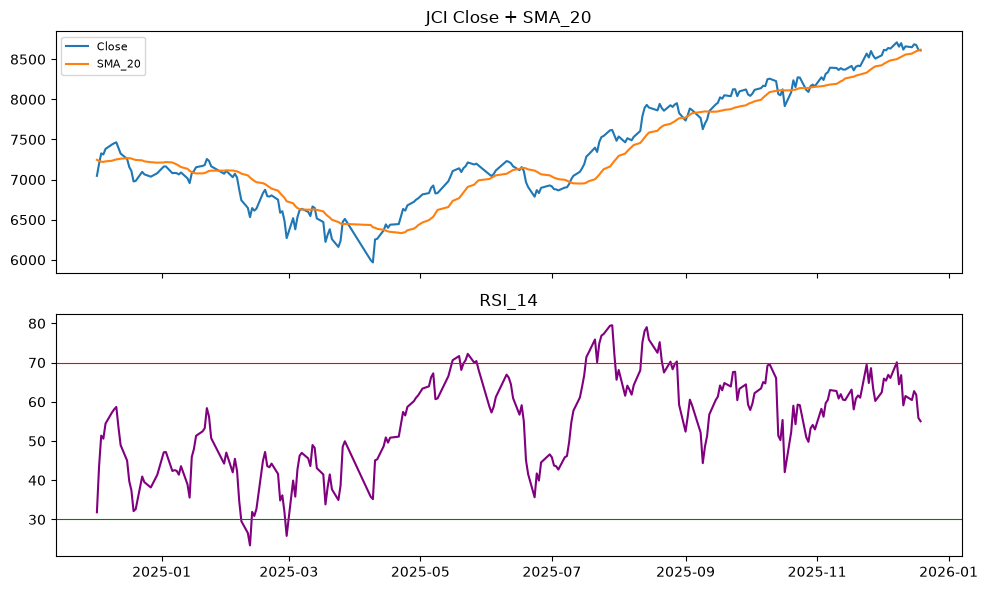

In [6]:
tail = df.tail(250)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax.plot(tail["Date"], tail["Close"], label="Close")
ax.plot(tail["Date"], tail["SMA_20"], label="SMA_20")
ax.legend(fontsize=8)
ax.set_title("JCI Close + SMA_20")
ax2.plot(tail["Date"], tail["RSI_14"], color="purple")
ax2.axhline(70, color="red", linewidth=0.8)
ax2.axhline(30, color="green", linewidth=0.8)
ax2.set_title("RSI_14")
plt.tight_layout()
plt.show()

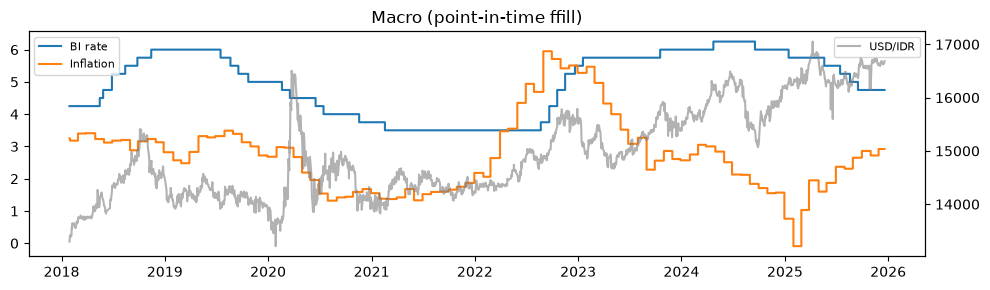

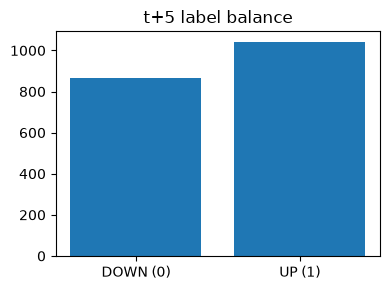

tensor shapes: (1881, 28, 7) (1881, 3) (1881, 768)


In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(df["Date"], df["bi_rate"], label="BI rate")
ax.step(df["Date"], df["inflation_rate"], label="Inflation")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Macro (point-in-time ffill)")
ax2 = ax.twinx()
ax2.plot(df["Date"], df["usd_idr"], color="gray", alpha=0.6, label="USD/IDR")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

counts = df["target_direction"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["DOWN (0)", "UP (1)"], [counts.get(0.0, 0), counts.get(1.0, 0)])
ax.set_title(f"t+{CFG.horizon} label balance")
plt.tight_layout()
plt.show()
print("tensor shapes:", t.X_tech.shape, t.X_macro.shape, t.X_news.shape)

## Checks

Shapes, finiteness, binary labels, and proof the scalers saw the train prefix only.

In [8]:
assert t.X_tech.shape[1:] == (lb, len(CFG.tech_cols))
assert len(t.y) == n_win
assert np.isfinite(t.X_tech).all() and np.isfinite(t.X_macro).all()
assert set(np.unique(t.y)) <= {0.0, 1.0}
raw_tech = df[list(CFG.tech_cols)].values.astype(np.float32)
assert np.allclose(feat_scaler.data_min_, raw_tech[:train_end_df].min(axis=0))
print("OK: leak-free single-notebook run passed")

OK: leak-free single-notebook run passed
